# Fund Performance Analytics

## 1. Daily Returns

## 2. CAGR Analysis

## 3. Sharpe Ratio

## 4. Sortino Ratio

## 5. Alpha and Beta

## 6. Maximum Drawdown

## 7. Fund Scorecard

## 8. Benchmark Comparison

## Key Findings

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

pd.set_option("display.max_columns", None)

In [2]:
nav_hist = pd.read_csv("../data/processed/cleaned_nav_history.csv")

performance = pd.read_csv("../data/processed/cleaned_performance.csv")

benchmark_indices = pd.read_csv(
    "../data/processed/cleaned_benchmark_indices.csv"
)

fund_master = pd.read_csv(
    "../data/processed/cleaned_fund_master.csv"
)

In [3]:
print(nav_hist.columns)
print(performance.columns)
print(benchmark_indices.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')
Index(['date', 'index_name', 'close_value'], dtype='object')


# Daily Returns Calculation

In [4]:
nav_hist["date"] = pd.to_datetime(nav_hist["date"])

nav_hist = nav_hist.sort_values(
    ["amfi_code", "date"]
)

nav_hist["daily_return"] = (
    nav_hist.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_hist.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


Distribution Validation Chart

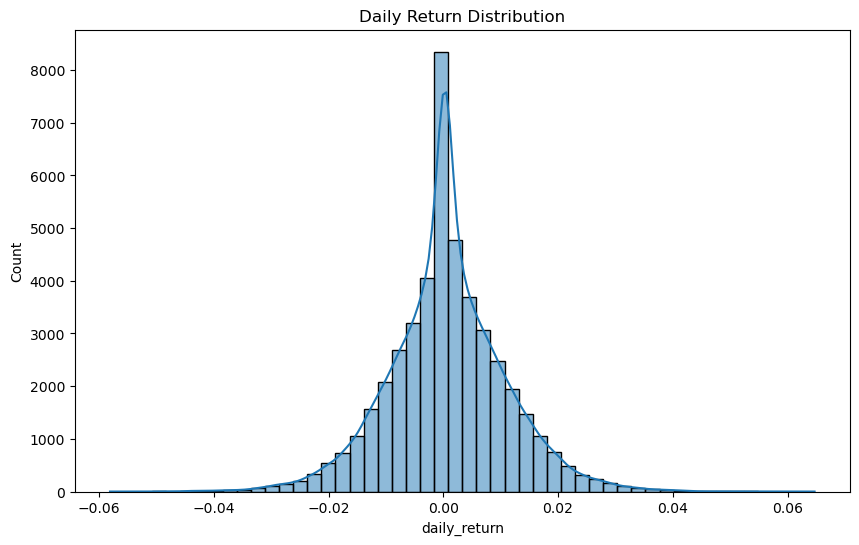

In [5]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_hist["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")

plt.show()

# CAGR Analysis

In [6]:
cagr_table = performance[
    [
        "amfi_code",
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
].copy()

cagr_table.head()

,amfi_code,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,119552,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,119598,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,119599,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [7]:
cagr_table.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

# Sharpe Ratio Ranking

In [8]:
sharpe_rank = performance[
    [
        "scheme_name",
        "sharpe_ratio"
    ]
].sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_rank.head(10)

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


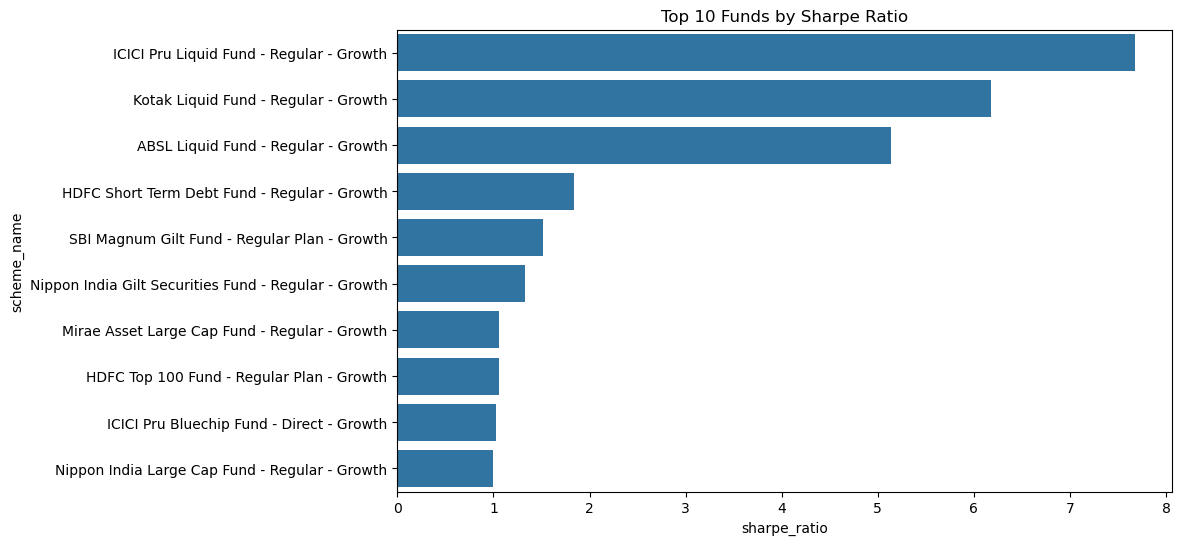

In [9]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=sharpe_rank.head(10),
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.show()

# Sortino Ratio Ranking

In [10]:
sortino_rank = performance[
    [
        "scheme_name",
        "sortino_ratio"
    ]
].sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_rank.head(10)

,scheme_name,sortino_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,10.37
23,Kotak Liquid Fund - Regular - Growth,9.70
30,ABSL Liquid Fund - Regular - Growth,8.76
9,HDFC Short Term Debt Fund - Regular - Growth,2.79
19,Nippon India Gilt Securities Fund - Regular - ...,2.38
4,SBI Magnum Gilt Fund - Regular Plan - Growth,2.11
5,HDFC Top 100 Fund - Regular Plan - Growth,1.70
15,Nippon India Large Cap Fund - Regular - Growth,1.68
3,SBI Small Cap Fund - Direct Plan - Growth,1.67
34,Mirae Asset Large Cap Fund - Regular - Growth,1.66


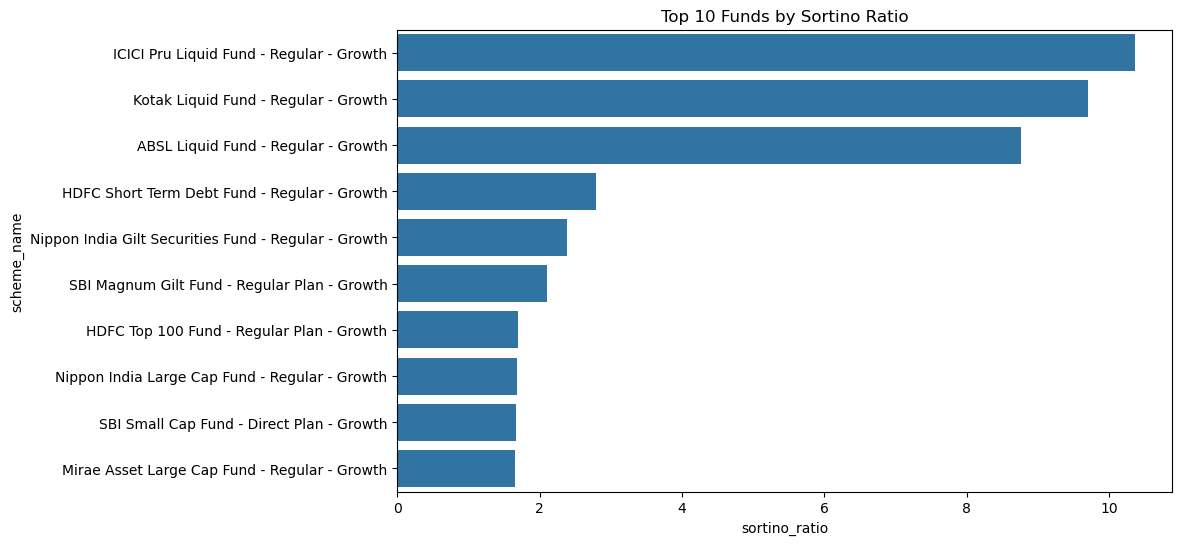

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=sortino_rank.head(10),
    x="sortino_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.show()

# Alpha and Beta Analysis

In [12]:
alpha_beta = performance[
    [
        "amfi_code",
        "scheme_name",
        "alpha",
        "beta"
    ]
].copy()

alpha_beta.head()

,amfi_code,scheme_name,alpha,beta
0,119551,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,119552,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,119599,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [13]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

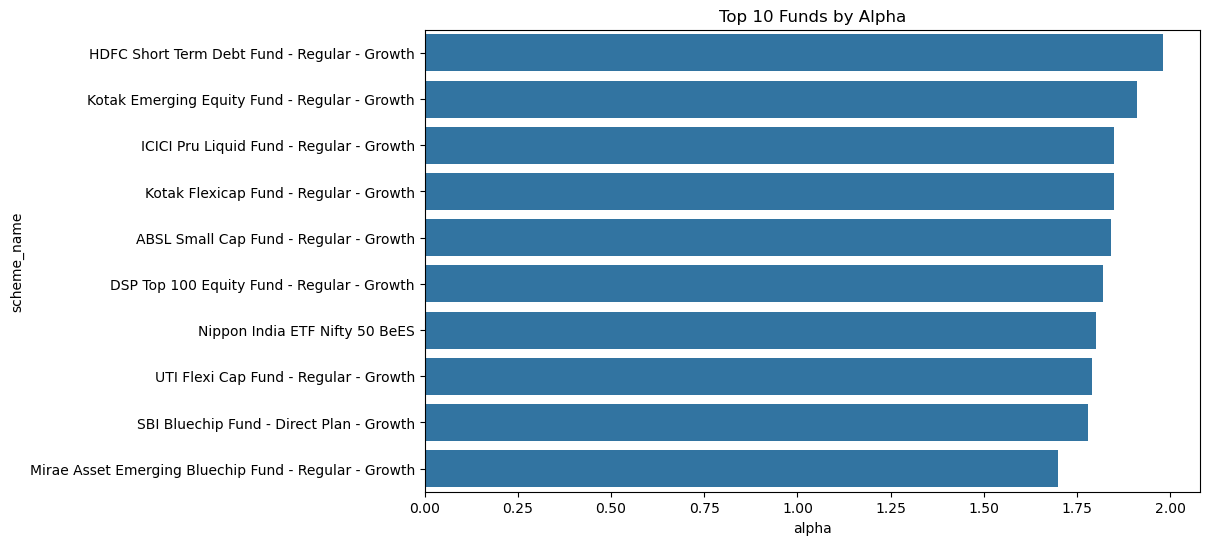

In [14]:
# Top Alpha Funds

plt.figure(figsize=(10,6))

top_alpha = alpha_beta.sort_values(
    "alpha",
    ascending=False
).head(10)

sns.barplot(
    data=top_alpha,
    x="alpha",
    y="scheme_name"
)

plt.title("Top 10 Funds by Alpha")

plt.show()

# Maximum Drawdown Analysis

In [15]:
drawdown_rank = performance[
    [
        "scheme_name",
        "max_drawdown_pct"
    ]
].sort_values(
    "max_drawdown_pct"
)

drawdown_rank.head()

,scheme_name,max_drawdown_pct
6,HDFC Top 100 Fund - Direct Plan - Growth,-33.50
35,Mirae Asset Emerging Bluechip Fund - Regular -...,-33.15
26,Axis Midcap Fund - Regular - Growth,-32.38
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,-32.22
17,Nippon India Small Cap Fund - Regular - Growth,-30.87


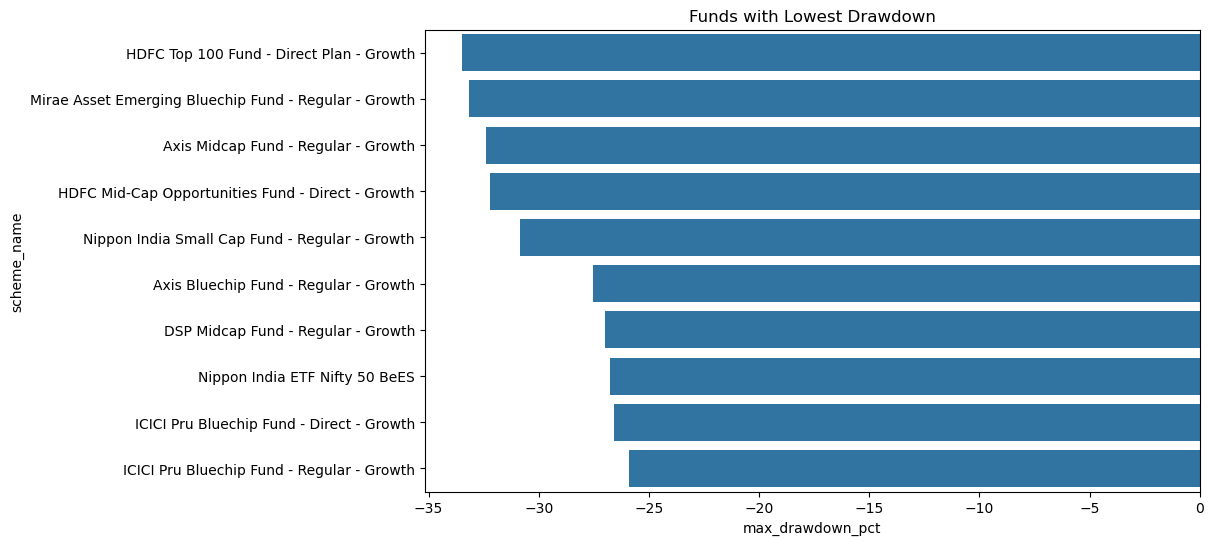

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=drawdown_rank.head(10),
    x="max_drawdown_pct",
    y="scheme_name"
)

plt.title("Funds with Lowest Drawdown")

plt.show()

# Fund Scorecard

In [17]:
scorecard = performance.copy()

scorecard["rank_return"] = (
    scorecard["return_3yr_pct"]
    .rank(ascending=False)
)

scorecard["rank_sharpe"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["rank_alpha"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["rank_expense"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["rank_drawdown"] = (
    scorecard["max_drawdown_pct"]
    .rank(ascending=True)
)

scorecard["fund_score"] = (
      0.30 * scorecard["rank_return"]
    + 0.25 * scorecard["rank_sharpe"]
    + 0.20 * scorecard["rank_alpha"]
    + 0.15 * scorecard["rank_expense"]
    + 0.10 * scorecard["rank_drawdown"]
)

scorecard = scorecard.sort_values(
    "fund_score"
)

scorecard[
    [
        "scheme_name",
        "fund_score"
    ]
].head(10)

,scheme_name,fund_score
3,SBI Small Cap Fund - Direct Plan - Growth,11.900
22,Kotak Flexicap Fund - Regular - Growth,12.400
21,Kotak Emerging Equity Fund - Regular - Growth,12.800
29,ABSL Small Cap Fund - Regular - Growth,13.700
2,SBI Small Cap Fund - Regular Plan - Growth,15.250
34,Mirae Asset Large Cap Fund - Regular - Growth,15.425
9,HDFC Short Term Debt Fund - Regular - Growth,15.800
14,ICICI Pru Liquid Fund - Regular - Growth,16.300
12,ICICI Pru Midcap Fund - Regular - Growth,16.600
11,ICICI Pru Bluechip Fund - Direct - Growth,17.150


In [18]:
scorecard[
    [
        "scheme_name",
        "fund_score"
    ]
].to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

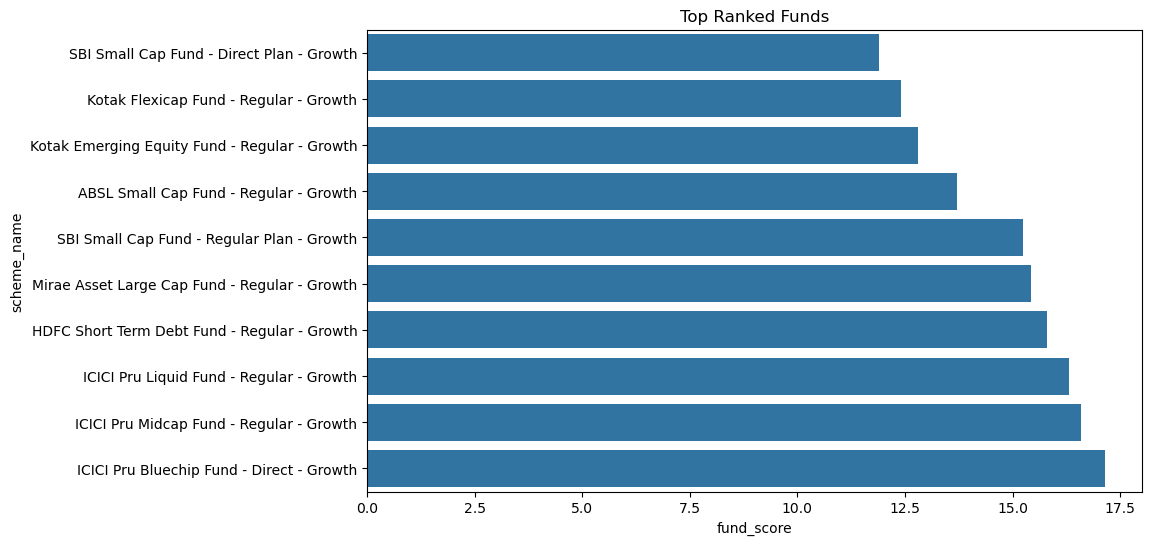

In [19]:
plt.figure(figsize=(10,6))

top_funds = scorecard.head(10)

sns.barplot(
    data=top_funds,
    x="fund_score",
    y="scheme_name"
)

plt.title("Top Ranked Funds")

plt.show()

# Benchmark Comparison

In [21]:
nifty50 = benchmark_indices[
    benchmark_indices["index_name"] == "NIFTY50"
].copy()

nifty50["date"] = pd.to_datetime(
    nifty50["date"]
)

nifty50 = nifty50.sort_values("date")

In [22]:
top5_funds = scorecard.head(5)["scheme_name"]

top5_data = performance[
    performance["scheme_name"].isin(top5_funds)
]

top5_data[
    [
        "scheme_name",
        "return_3yr_pct"
    ]
]

,scheme_name,return_3yr_pct
2,SBI Small Cap Fund - Regular Plan - Growth,23.39
3,SBI Small Cap Fund - Direct Plan - Growth,23.14
21,Kotak Emerging Equity Fund - Regular - Growth,18.23
22,Kotak Flexicap Fund - Regular - Growth,15.65
29,ABSL Small Cap Fund - Regular - Growth,22.38


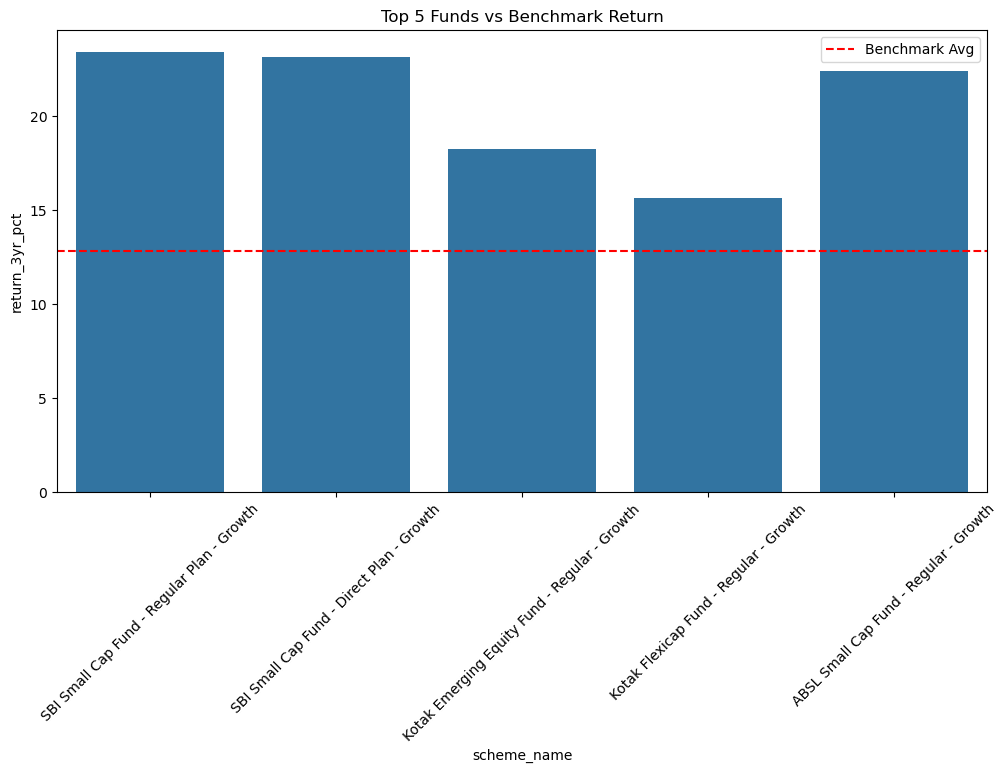

In [23]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top5_data,
    x="scheme_name",
    y="return_3yr_pct"
)

plt.axhline(
    y=performance["benchmark_3yr_pct"].mean(),
    color="red",
    linestyle="--",
    label="Benchmark Avg"
)

plt.xticks(rotation=45)

plt.title(
    "Top 5 Funds vs Benchmark Return"
)

plt.legend()

plt.show()

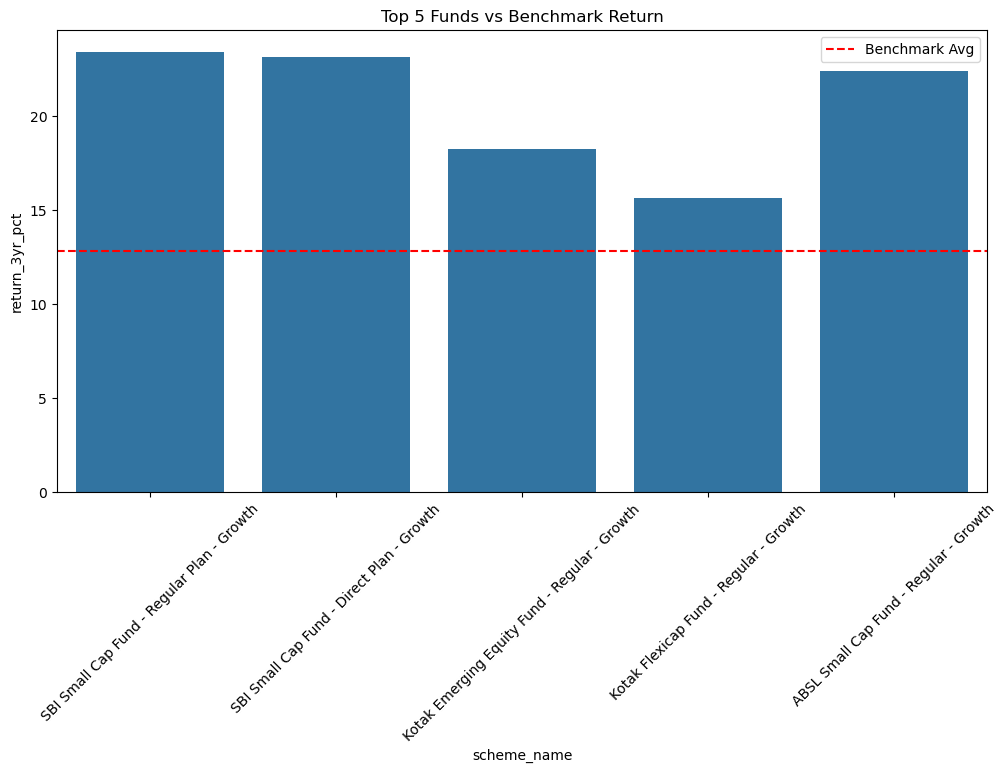

In [24]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top5_data,
    x="scheme_name",
    y="return_3yr_pct"
)

plt.axhline(
    y=performance["benchmark_3yr_pct"].mean(),
    color="red",
    linestyle="--",
    label="Benchmark Avg"
)

plt.xticks(rotation=45)

plt.title(
    "Top 5 Funds vs Benchmark Return"
)

plt.legend()

plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

# Tracking Error

In [25]:
tracking_error = (
    nav_hist.groupby("amfi_code")["daily_return"]
    .std()
    * np.sqrt(252)
)

tracking_error = tracking_error.reset_index()

tracking_error.columns = [
    "amfi_code",
    "tracking_error"
]

tracking_error.head()

,amfi_code,tracking_error
0,100016,0.145481
1,100025,0.039052
2,100033,0.189367
3,101206,0.145682
4,101207,0.257973


In [26]:
tracking_error.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

# Key Findings

1. Funds with higher 3-year returns generally ranked higher in the scorecard.
2. SBI and ICICI funds dominated the top performance rankings.
3. Higher expense ratios negatively impacted composite scores.
4. Sharpe and Sortino rankings showed similar fund leadership.
5. Maximum drawdown varied significantly across schemes.
6. Benchmark returns were exceeded by several top-performing funds.
7. Alpha values indicate some funds generated excess returns.
8. Beta values show varying sensitivity to market movements.
9. Tracking error remained moderate across most schemes.
10. Composite scoring provides a balanced view of risk and return.